# CTR Acceleration Backend Benchmark

Benchmark the CTR structure-factor backends for a representative test crystal. The notebook compares the original NumPy path with the optional C++ and Numba acceleration backends when they are available.

The first accelerated call may include setup or compilation overhead, so the benchmark does an explicit warmup before recording timings. The reported timings are runtime-only measurements after warmup.

The accelerated CTR kernels are intentionally single-threaded at this level. This benchmark measures the benefit from fused loops, low temporary-array allocation, and compiler optimization without adding thread parallelism inside the structure-factor kernels.


## Setup

Start Jupyter from the `benchmarks/` directory and run this notebook there. The benchmark imports the installed `orgui` package from the active Python environment. The benchmark uses the copied CTR regression fixture in `benchmarks/fixtures/0V12_calculated.xpr`.


## Backend Selection

CTR structure-factor calculations default to C++ when the extension is available and run the explicit NumPy structure-factor path otherwise. Numba is not imported automatically unless selected. To select the active process-global backend before importing `CTRuc`, set the shared backend variable:

```bash
ORGUI_ACCEL_BACKEND=cpp python my_ctr_script.py
ORGUI_ACCEL_BACKEND=numba python my_ctr_script.py
ORGUI_ACCEL_BACKEND=numpy python my_ctr_script.py
```

The same selection can be changed inside a Python process:

```python
from orgui.datautils.xrayutils import CTRuc

CTRuc.set_accel_backend("cpp")
CTRuc.set_accel_backend("numba")
CTRuc.set_accel_backend("numpy")  # disable acceleration
```

`CTRuc.set_accel_backend("numba")` raises `ValueError` if the optional Numba backend cannot be imported. See **Acceleration Backends** in the main documentation for the ROI and CTR selector summary.


In [1]:
from pathlib import Path
import statistics
import time

import numpy as np


BENCHMARK_DIR = Path.cwd().resolve()
FIXTURE_CANDIDATES = (
    BENCHMARK_DIR / "fixtures",
    BENCHMARK_DIR.parents[2] / "benchmarks" / "fixtures",
)
FIXTURE_DIR = next((path for path in FIXTURE_CANDIDATES if path.is_dir()), None)
if FIXTURE_DIR is None:
    raise FileNotFoundError(
        "Could not find benchmark fixtures. Run from benchmarks/ or execute "
        "this notebook from doc/source/benchmarks/."
    )
XPR_PATH = FIXTURE_DIR / "0V12_calculated.xpr"

if (BENCHMARK_DIR / "orgui").is_dir():
    raise RuntimeError(
        "Notebook is running from the repository root. Start Jupyter from "
        "benchmarks/ to benchmark the installed package."
    )

print(f"Benchmark directory: {BENCHMARK_DIR}")
print(f"Fixture:             {XPR_PATH}")


Benchmark directory: C:\Users\timof\Documents\repos\orGUI\doc\source\benchmarks
Fixture:             C:\Users\timof\Documents\repos\orGUI\benchmarks\fixtures\0V12_calculated.xpr


In [2]:
!hostname


CTRsurfacePC


In [3]:
from orgui import __version__, get_build_config
print("orGUI version", __version__)
print(get_build_config())


orGUI version 1.5.1.dev69+gaf90fcda9.d20260724
{'native_optimization': False, 'target_cpu': 'generic', 'allowed_instruction_set': [], 'native_arguments': '', 'cpp_compiler_id': 'msvc', 'cpp_compiler_version': '19.43.34810', 'host_system': 'windows', 'host_cpu_family': 'x86_64', 'host_cpu': 'x86_64', 'available': True}


In [4]:
from orgui.datautils import util
from orgui.datautils.xrayutils import CTRcalc, CTRuc


AVAILABLE_BACKENDS = ["numpy"]
if CTRuc.HAS_CPP_ACCEL:
    AVAILABLE_BACKENDS.append("cpp")
if CTRuc.ctr_numba_accel_available():
    AVAILABLE_BACKENDS.append("numba")

print(f"Default CTR acceleration backend: {CTRuc.CTR_ACCEL_BACKEND}")
print(f"Available CTR acceleration backends: {AVAILABLE_BACKENDS}")


Default CTR acceleration backend: cpp
Available CTR acceleration backends: ['numpy', 'cpp', 'numba']


## Benchmark Helpers

`CTRuc.CTR_ACCEL_BACKEND` selects the active implementation. Use `CTRuc.set_accel_backend("cpp" | "numba" | "numpy")` to compare the direct C++ extension, Numba kernels, and original NumPy implementation.


In [5]:
def set_backend(backend):
    CTRuc.set_accel_backend(backend)


def load_crystal():
    xtal = CTRcalc.SXRDCrystal.fromFile(XPR_PATH)
    pt100 = CTRcalc.UnitCell(
        [3.9242, 3.9242, 3.9242],
        [90.0, 90.0, 90.0],
    )
    xtal.setGlobalReferenceUnitCell(
        pt100,
        util.z_rotation(np.deg2rad(45.0)),
    )
    return xtal


def make_rod(n_points):
    l_values = np.ascontiguousarray(
        np.linspace(0.05, 7.0, n_points),
        dtype=np.float64,
    )
    zeros = np.zeros_like(l_values)
    return zeros, zeros, l_values


def time_call(func, repeats=7, warmups=1):
    for _ in range(warmups):
        func()

    timings = []
    for _ in range(repeats):
        start = time.perf_counter()
        func()
        timings.append(time.perf_counter() - start)

    return {
        "min_s": min(timings),
        "median_s": statistics.median(timings),
        "mean_s": statistics.mean(timings),
        "repeats": repeats,
    }


def format_seconds(value):
    if value < 1e-3:
        return f"{value * 1e6:8.1f} us"
    if value < 1:
        return f"{value * 1e3:8.2f} ms"
    return f"{value:8.3f} s"


def cold_cache_time(func, repeats=7):
    """Return a median with the global cache cleared before every call."""
    timings = []
    for _ in range(repeats):
        CTRuc.clear_form_factor_cache()
        start = time.perf_counter()
        func()
        timings.append(time.perf_counter() - start)
    return statistics.median(timings)



## Warmup and Correctness Check

The accelerated and non-accelerated paths should produce the same complex amplitudes within normal floating-point tolerance before any timing results are trusted.


In [6]:
xtal = load_crystal()
h, k, l = make_rod(2_000)

set_backend("numpy")
numpy_uc = xtal.uc_bulk.F_uc(h, k, l)
numpy_xtal = xtal.F(h, k, l)

for backend in AVAILABLE_BACKENDS:
    if backend == "numpy":
        continue
    set_backend(backend)
    backend_uc = xtal.uc_bulk.F_uc(h, k, l)
    backend_xtal = xtal.F(h, k, l)
    np.testing.assert_allclose(backend_uc, numpy_uc, rtol=1e-12, atol=1e-12)
    np.testing.assert_allclose(backend_xtal, numpy_xtal, rtol=1e-10, atol=1e-10)

print("Available accelerated backends match NumPy for UnitCell.F_uc and SXRDCrystal.F")


Available accelerated backends match NumPy for UnitCell.F_uc and SXRDCrystal.F


## Structure-Factor and C++ Form-Factor Cache Benchmarks

The first table measures direct repeated structure-factor evaluations for increasing CTR rod lengths. The cache table then measures canonical `UnitCell.F_uc` with no resident cache, with a cleared cache before each call, and with a pre-populated cache.

Exact cache reuse requires bitwise-identical computed float64 Q-squared vectors and complete 13-value Waasmaier rows. The cache is process-global; its 256 MiB LRU budget counts retained Q-squared and real form-factor vectors, not call-local arrays or output arrays.


In [7]:
def benchmark_structure_factor(n_points, repeats=7):
    xtal = load_crystal()
    h, k, l = make_rod(n_points)

    def run_unitcell(backend):
        set_backend(backend)
        return lambda: xtal.uc_bulk.F_uc(h, k, l)

    def run_crystal(backend):
        set_backend(backend)
        return lambda: xtal.F(h, k, l)

    rows = []
    for label, factory in (
        ("UnitCell.F_uc", run_unitcell),
        ("SXRDCrystal.F", run_crystal),
    ):
        stats = {
            backend: time_call(factory(backend), repeats=repeats)
            for backend in AVAILABLE_BACKENDS
        }
        row = {
            "benchmark": label,
            "points": n_points,
        }
        for backend, backend_stats in stats.items():
            row[f"{backend}_median_s"] = backend_stats["median_s"]
            row[f"{backend}_min_s"] = backend_stats["min_s"]
        for backend in AVAILABLE_BACKENDS:
            if backend == "numpy":
                continue
            row[f"{backend}_speedup"] = (
                row["numpy_median_s"] / row[f"{backend}_median_s"]
            )
        rows.append(row)
    return rows


results = []
for n_points in (200, 2_000, 20_000):
    results.extend(benchmark_structure_factor(n_points))

header = f"{'benchmark':<18} {'points':>8}"
for backend in AVAILABLE_BACKENDS:
    header += f" {backend + ' median':>15}"
for backend in AVAILABLE_BACKENDS:
    if backend != "numpy":
        header += f" {backend + ' speedup':>14}"
print(header)
for row in results:
    line = f"{row['benchmark']:<18} {row['points']:>8}"
    for backend in AVAILABLE_BACKENDS:
        line += f" {format_seconds(row[f'{backend}_median_s']):>15}"
    for backend in AVAILABLE_BACKENDS:
        if backend != "numpy":
            line += f" {row[f'{backend}_speedup']:>13.2f}x"
    print(line)


benchmark            points    numpy median      cpp median    numba median    cpp speedup  numba speedup
UnitCell.F_uc           200        169.7 us         57.3 us         25.8 us          2.96x          6.58x
SXRDCrystal.F           200        496.3 us        114.0 us        121.8 us          4.35x          4.07x
UnitCell.F_uc          2000        407.2 us        150.2 us        301.5 us          2.71x          1.35x
SXRDCrystal.F          2000         1.56 ms        674.8 us        950.7 us          2.30x          1.64x
UnitCell.F_uc         20000         3.32 ms         1.40 ms         2.91 ms          2.37x          1.14x
SXRDCrystal.F         20000        10.34 ms         5.00 ms         8.01 ms          2.07x          1.29x


## Benchmark Results

The plot compares structure-factor backend medians. The following table reports the canonical C++ `UnitCell.F_uc` cache runs: uncached, cold cache, and warm cache, together with cache counters and retained-versus-expected numerical bytes.


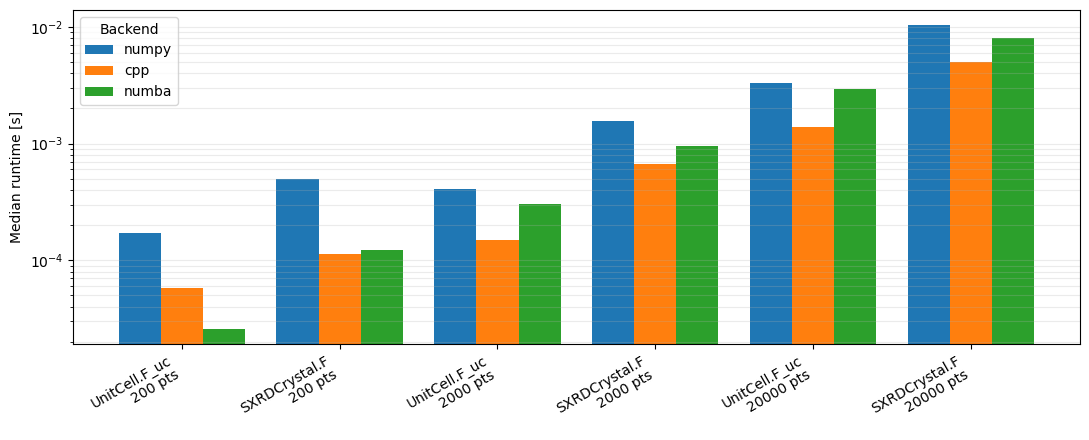

In [8]:
from matplotlib import pyplot as plt

labels = [f"{row['benchmark']}\n{row['points']} pts" for row in results]
x = np.arange(len(labels))
width = min(0.8 / len(AVAILABLE_BACKENDS), 0.28)
offsets = (np.arange(len(AVAILABLE_BACKENDS)) - (len(AVAILABLE_BACKENDS) - 1) / 2) * width

fig, ax = plt.subplots(figsize=(11, 4.5))
for offset, backend in zip(offsets, AVAILABLE_BACKENDS):
    ax.bar(
        x + offset,
        [row[f"{backend}_median_s"] for row in results],
        width,
        label=backend,
    )

ax.set_ylabel("Median runtime [s]")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.legend(title="Backend")
ax.grid(axis="y", which="both", alpha=0.25)
fig.tight_layout()


In [9]:
def benchmark_form_factor_cache(n_points, repeats=7):
    if not CTRuc.HAS_CPP_ACCEL:
        return None

    xtal = load_crystal()
    h, k, l = make_rod(n_points)

    def run_unitcell():
        return xtal.uc_bulk.F_uc(h, k, l)

    set_backend("cpp")
    original_budget = CTRuc.form_factor_cache_stats()["budget_bytes"]
    CTRuc.clear_form_factor_cache()
    CTRuc.reset_form_factor_cache_stats()
    try:
        CTRuc.set_form_factor_cache_budget(0)
        uncached = time_call(run_unitcell, repeats=repeats)["median_s"]

        CTRuc.set_form_factor_cache_budget(original_budget)
        cold = cold_cache_time(run_unitcell, repeats=repeats)

        CTRuc.clear_form_factor_cache()
        run_unitcell()
        warm = time_call(run_unitcell, repeats=repeats, warmups=0)["median_s"]
        stats = CTRuc.form_factor_cache_stats()
    finally:
        CTRuc.clear_form_factor_cache()
        CTRuc.set_form_factor_cache_budget(original_budget)

    return {
        "points": n_points,
        "uncached_median_s": uncached,
        "cold_median_s": cold,
        "warm_median_s": warm,
        "warm_speedup": uncached / warm,
        "resident_bytes": stats["resident_bytes"],
        "expected_bytes": CTRuc.form_factor_cache_expected_bytes(
            n_points, stats["species_entries"]
        ),
        "hits": stats["hits"],
        "misses": stats["misses"],
        "evictions": stats["evictions"],
    }


cache_results = [
    benchmark_form_factor_cache(n_points)
    for n_points in (2_000, 20_000, 200_000)
]
cache_results = [result for result in cache_results if result is not None]

if not cache_results:
    print("C++ extension unavailable; cache benchmark skipped.")
else:
    print(
        f"{'points':>8} {'uncached':>14} {'cold':>14} {'warm':>14} "
        f"{'speedup':>9} {'hits':>7} {'misses':>7} {'evictions':>10} "
        f"{'resident':>12} {'expected':>12}"
    )
    for row in cache_results:
        print(
            f"{row['points']:8d} "
            f"{format_seconds(row['uncached_median_s']):>14} "
            f"{format_seconds(row['cold_median_s']):>14} "
            f"{format_seconds(row['warm_median_s']):>14} "
            f"{row['warm_speedup']:8.2f}x "
            f"{row['hits']:7d} {row['misses']:7d} {row['evictions']:10d} "
            f"{row['resident_bytes']:11d}B {row['expected_bytes']:11d}B"
        )

  points       uncached           cold           warm   speedup    hits  misses  evictions     resident     expected
    2000       154.9 us       155.8 us       106.4 us     1.46x       7      16          0       32000B       32000B
   20000        1.67 ms        2.16 ms        1.18 ms     1.42x       7      16          0      320000B      320000B
  200000       20.36 ms       20.90 ms       14.21 ms     1.43x       7      16          0     3200000B     3200000B
